In [1]:
# ============================================================
# PRÁCTICA FINAL - APRENDIZAJE PROFUNDO
# Caso: Clasificación de cobertura terrestre con EuroSAT
# Entorno: Kaggle Notebook / Google Colab
# ============================================================
import os
import zipfile
import requests
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 10
SEED       = 123

print("TensorFlow:", tf.__version__)

2026-06-04 16:17:36.465921: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780589856.701148      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780589856.769369      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780589857.370032      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780589857.370067      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780589857.370070      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


In [2]:
# ============================================================
# 1. DESCARGA DEL DATASET EUROSAT RGB
# Fuente oficial: https://github.com/phelber/EuroSAT
# ============================================================
url = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"
zip_path = "EuroSAT.zip"

if not os.path.exists(zip_path):
    print("Descargando EuroSAT...")
    response = requests.get(url, verify=False)
    with open(zip_path, "wb") as f:
        f.write(response.content)

if not os.path.exists("2750"):
    print("Descomprimiendo dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(".")

DATA_DIR = "2750"
print("Dataset listo en:", DATA_DIR)

Descargando EuroSAT...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'madm.dfki.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Descomprimiendo dataset...
Dataset listo en: 2750


In [3]:
# ============================================================
# 2. CARGA DEL DATASET Y PARTICIÓN ENTRENAMIENTO/VALIDACIÓN
# ============================================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Clases:", class_names)
print("Número de clases:", NUM_CLASSES)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 27000 files belonging to 10 classes.
Using 21600 files for training.


I0000 00:00:1780589891.585630      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780589891.591762      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Clases: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Número de clases: 10


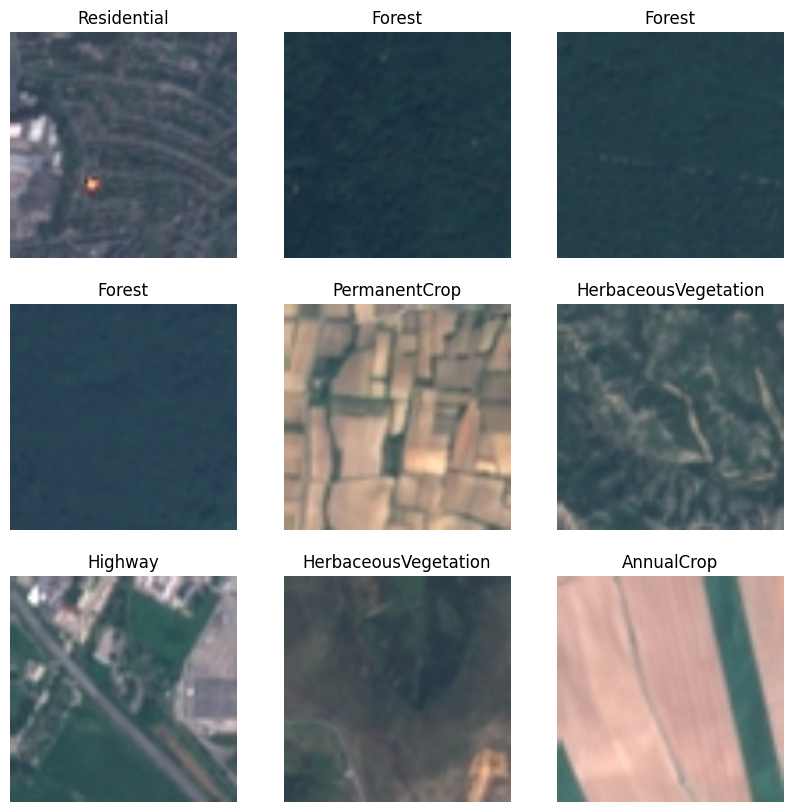

In [4]:
# ============================================================
# 3. VISUALIZACIÓN DE MUESTRAS REALES DEL DATASET
# ============================================================
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [6]:
# ============================================================
# 4. DATA AUGMENTATION
# Mejora la generalización del modelo mediante transformaciones.
# ============================================================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [7]:
# ============================================================
# 5. CNN PROPIA DESDE CERO
# ============================================================
cnn_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

callbacks_cnn = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint("cnn_eurosat.keras", save_best_only=True)
]

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_cnn
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,247,242 (84.87 MB)

 Trainable params: 22,247,242 (84.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


I0000 00:00:1780590106.830570     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


675/675 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.4174 - loss: 1.6085 - val_accuracy: 0.5680 - val_loss: 1.2031
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.5813 - loss: 1.2008 - val_accuracy: 0.6409 - val_loss: 1.0162
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.6271 - loss: 1.0556 - val_accuracy: 0.6531 - val_loss: 0.9409
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 42s 62ms/step - accuracy: 0.6606 - loss: 0.9640 - val_accuracy: 0.7187 - val_loss: 0.7923
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 42s 62ms/step - accuracy: 0.6915 - loss: 0.8791 - val_accuracy: 0.7435 - val_loss: 0.7052
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 42s 62ms/step - accuracy: 0.7062 - loss: 0.8403 - val_accuracy: 0.7643 - val_loss: 0.6605
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.7213 - loss: 0.7939 - val_accuracy: 0.7567 - val_loss: 0.6727
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 42s 63ms/step - accuracy: 0.7288 - loss: 0.7711 - val_accurac

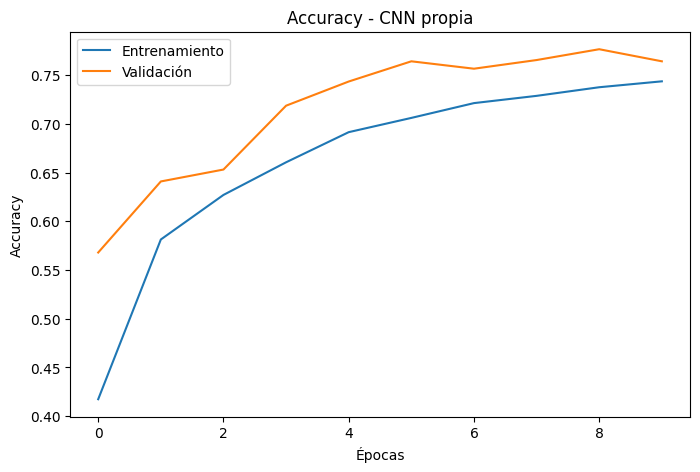

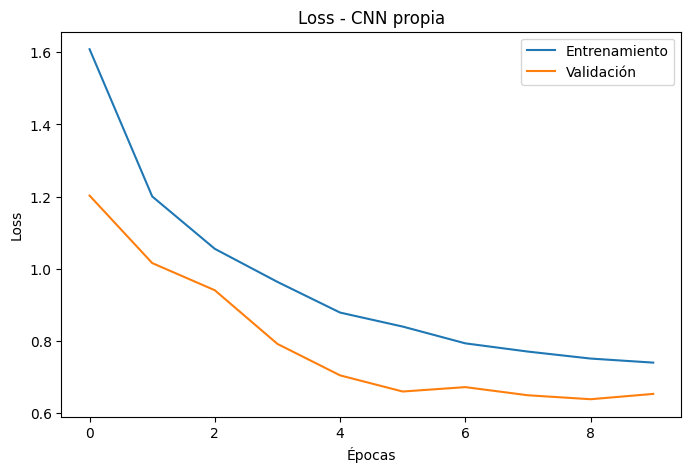

In [8]:
# ============================================================
# 6. GRÁFICOS DE ENTRENAMIENTO
# ============================================================
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Entrenamiento")
    plt.plot(history.history["val_accuracy"], label="Validación")
    plt.title("Accuracy - " + title)
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Entrenamiento")
    plt.plot(history.history["val_loss"], label="Validación")
    plt.title("Loss - " + title)
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history_cnn, "CNN propia")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


E0000 00:00:1780590675.084206      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


675/675 ━━━━━━━━━━━━━━━━━━━━ 70s 89ms/step - accuracy: 0.8675 - loss: 0.4618 - val_accuracy: 0.9252 - val_loss: 0.2335
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 58s 85ms/step - accuracy: 0.9166 - loss: 0.2522 - val_accuracy: 0.9365 - val_loss: 0.1930
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 59s 87ms/step - accuracy: 0.9282 - loss: 0.2146 - val_accuracy: 0.9422 - val_loss: 0.1760
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 59s 88ms/step - accuracy: 0.9300 - loss: 0.2056 - val_accuracy: 0.9487 - val_loss: 0.1653
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 59s 88ms/step - accuracy: 0.9361 - loss: 0.1904 - val_accuracy: 0.9502 - val_loss: 0.1559
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 60s 88ms/step - accuracy: 0.9371 - loss: 0.1856 - val_accuracy: 0.9506 - val_loss: 0.1536
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 60s 89ms/step - accuracy: 0.9354 - loss: 0.1843 - val_accuracy: 0.9522 - val_loss: 0.1516
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 60s 89ms/step - accuracy: 0.9411 - loss: 0.1717 - val_accurac

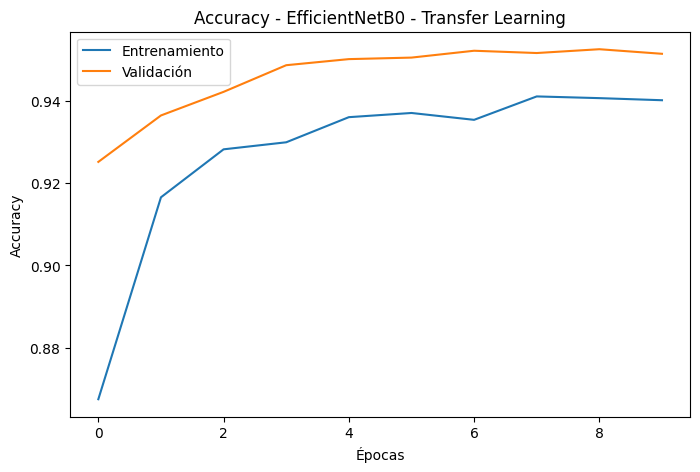

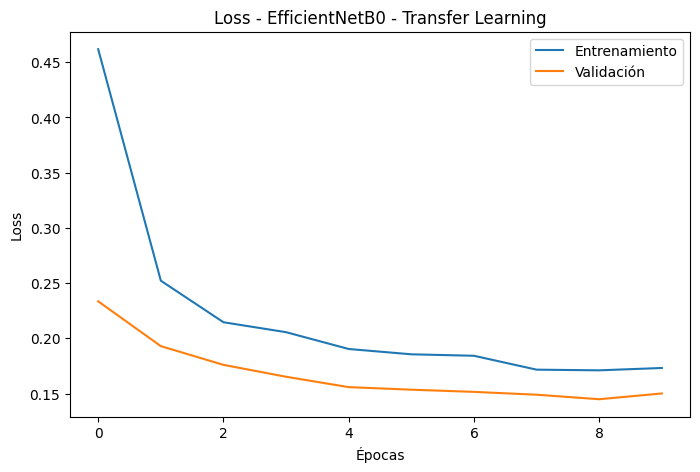

In [9]:
# ============================================================
# 7. TRANSFER LEARNING CON EFFICIENTNETB0
# ============================================================
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

efficient_model = models.Model(inputs, outputs)

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_eff = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint("efficientnet_eurosat.keras", save_best_only=True)
]

history_eff = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_eff
)

plot_history(history_eff, "EfficientNetB0 - Transfer Learning")

Epoch 1/5


E0000 00:00:1780591288.606621      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


675/675 ━━━━━━━━━━━━━━━━━━━━ 79s 100ms/step - accuracy: 0.8600 - loss: 0.4343 - val_accuracy: 0.9304 - val_loss: 0.2240
Epoch 2/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 65s 96ms/step - accuracy: 0.8992 - loss: 0.3070 - val_accuracy: 0.9378 - val_loss: 0.1951
Epoch 3/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 65s 97ms/step - accuracy: 0.9118 - loss: 0.2698 - val_accuracy: 0.9426 - val_loss: 0.1784


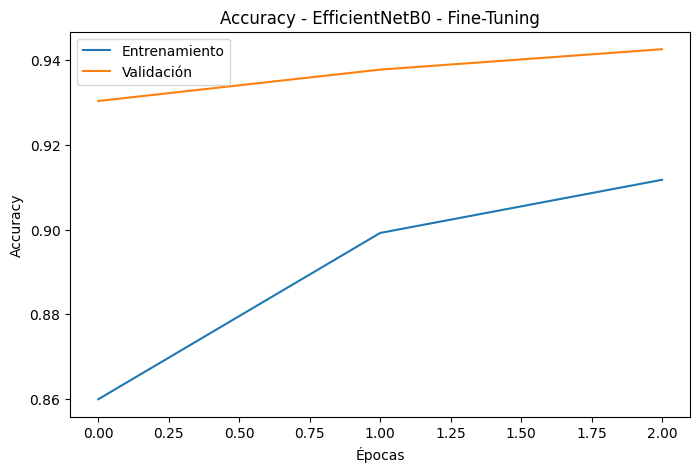

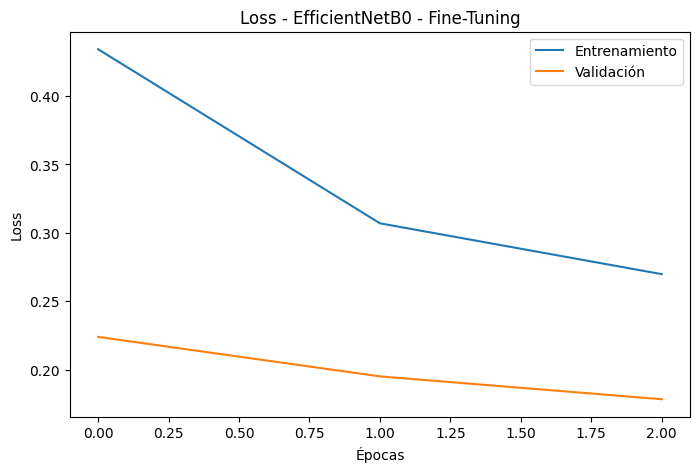

Modelo exportado: modelo_final_eurosat.keras


In [10]:
# ============================================================
# 8. FINE-TUNING
# Descongela las últimas capas del modelo base para ajustar
# características más específicas al dataset EuroSAT.
# ============================================================
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks_eff
)

plot_history(history_ft, "EfficientNetB0 - Fine-Tuning")

efficient_model.save("modelo_final_eurosat.keras")
print("Modelo exportado: modelo_final_eurosat.keras")

169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.9304 - loss: 0.2240
Pérdida final: 0.2239624261856079
Accuracy final: 0.9303703904151917
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step

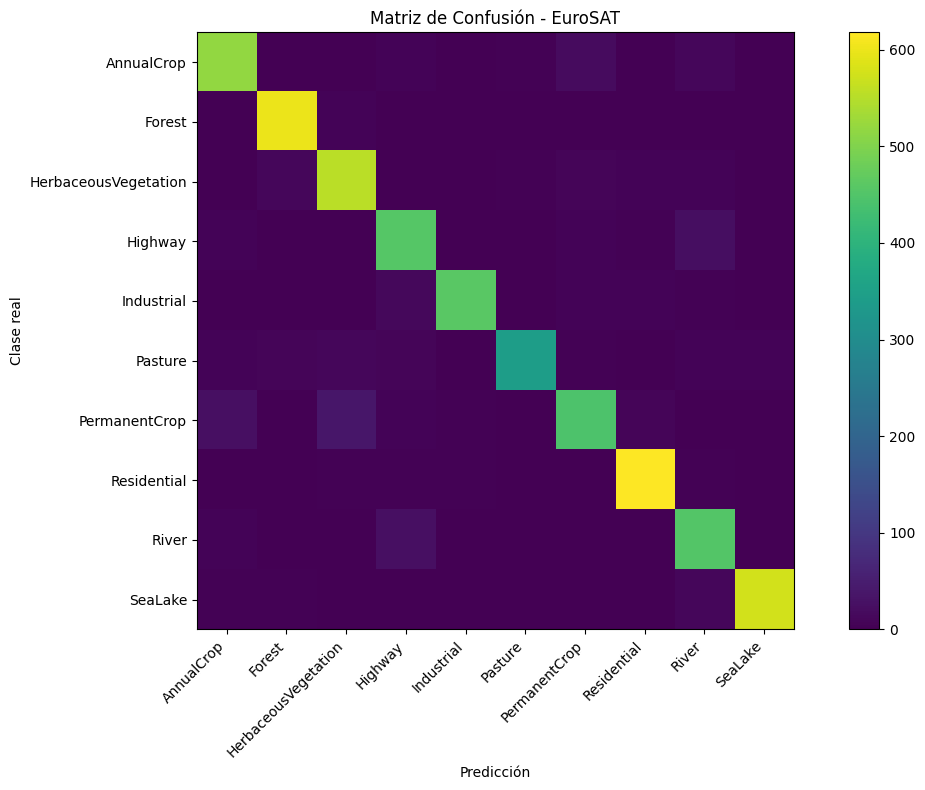

In [11]:
# ============================================================
# 9. EVALUACIÓN FINAL: MÉTRICAS Y MATRIZ DE CONFUSIÓN
# ============================================================
loss, accuracy = efficient_model.evaluate(val_ds)
print("Pérdida final:", loss)
print("Accuracy final:", accuracy)

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = efficient_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de Confusión - EuroSAT")
plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


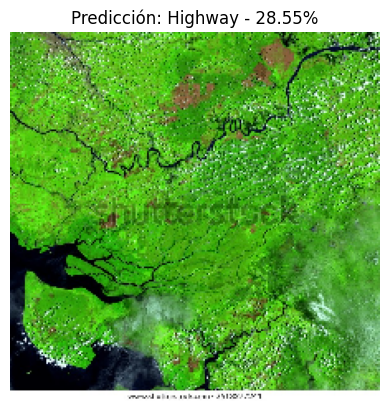

Clase reconocida: Highway
Probabilidad: 28.55 %


In [21]:
# ============================================================
# 10. SIMULACIÓN DE RECONOCIMIENTO CON UNA IMAGEN REAL
# La imagen debe estar en el entorno con el nombre imagen_prueba.jpg.
# ============================================================
from tensorflow.keras.preprocessing import image

def reconocer_imagen(ruta_imagen, modelo, clases):
    img = image.load_img(ruta_imagen, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    pred = modelo.predict(img_array)
    clase = clases[np.argmax(pred)]
    probabilidad = np.max(pred) * 100
    
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicción: {clase} - {probabilidad:.2f}%")
    plt.show()
    
    print("Clase reconocida:", clase)
    print("Probabilidad:", round(probabilidad, 2), "%")

# LLAMADA ACTIVA (Asegúrate de haber subido 'imagen_prueba.jpg' a tus archivos)
reconocer_imagen("imagen_prueba.jpg", efficient_model, class_names)

In [20]:
import requests

# Descargamos una imagen satelital real de un río (completamente externa a EuroSAT)
url_rio = "https://image.shutterstock.com/image-photo/satellite-imagery-west-borneo-sentinel-600w-2613277241.jpg"

try:
    response = requests.get(url_rio, verify=False)
    with open("imagen_prueba.jpg", "wb") as f:
        f.write(response.content)
    print("¡Logrado! Imagen de río externa guardada como 'imagen_prueba.jpg'")
except Exception as e:
    print("Hubo un error al descargar la imagen:", e)

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'image.shutterstock.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


¡Logrado! Imagen de río externa guardada como 'imagen_prueba.jpg'


In [ ]:
modelo.save_weights('modelo_final_eurosat.keras')